In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [7]:
x = np.arange(0, 10, 1)
y = np.random.randint(0, 10, (10,))

In [8]:
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [9]:
y

array([1, 4, 8, 5, 7, 1, 2, 1, 6, 9])

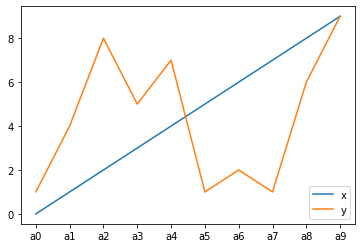

In [17]:
plt.plot(x)
plt.plot(y)
plt.legend(labels=['x', 'y'], loc='lower right')
plt.xticks(ticks=x, labels=['a'+str(i) for i in x]);

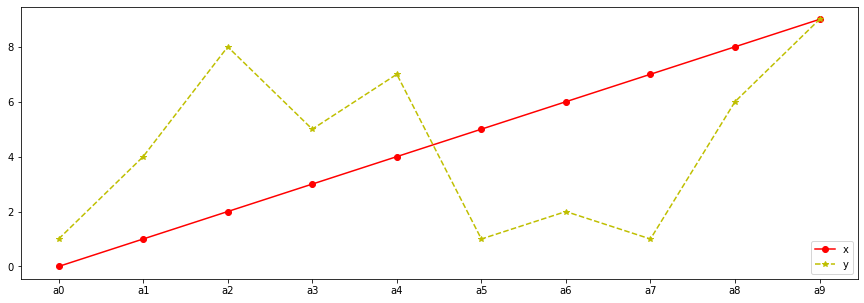

In [25]:
plt.figure(figsize=(15,5))
plt.plot(x, color='r', marker='o')
plt.plot(y, 'y--', marker='*')
plt.legend(labels=['x', 'y'], loc='lower right')
plt.xticks(ticks=x, labels=['a'+str(i) for i in x]);

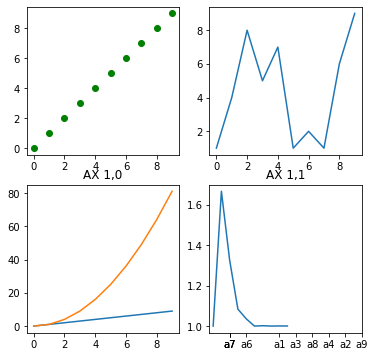

In [38]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(6,6))
ax[0, 0].plot(x, 'go')
ax[0, 1].plot(y)
ax[1, 0].plot(x)
ax[1, 0].plot(x**2)
ax[1, 1].plot(y**np.exp(-x))

ax[1,0].set_title('AX 1,0');
ax[1,1].set_title('AX 1,1');
ax[1, 1].set_xticks(ticks=2*y);
ax[1, 1].set_xticklabels(labels=['a'+str(i) for i in x]);

In [41]:
df = pd.read_csv('bigmart_data.csv')

In [42]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [44]:
df.columns.tolist()

['Item_Identifier',
 'Item_Weight',
 'Item_Fat_Content',
 'Item_Visibility',
 'Item_Type',
 'Item_MRP',
 'Outlet_Identifier',
 'Outlet_Establishment_Year',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type',
 'Item_Outlet_Sales']

In [57]:
price_item = df.groupby('Item_Type').Item_MRP.mean()[:10]
price_item

Item_Type
Baking Goods             126.380766
Breads                   140.952669
Breakfast                141.788151
Canned                   139.763832
Dairy                    148.499208
Frozen Foods             138.503366
Fruits and Vegetables    144.581235
Hard Drinks              137.077928
Health and Hygiene       130.818921
Household                149.424753
Name: Item_MRP, dtype: float64

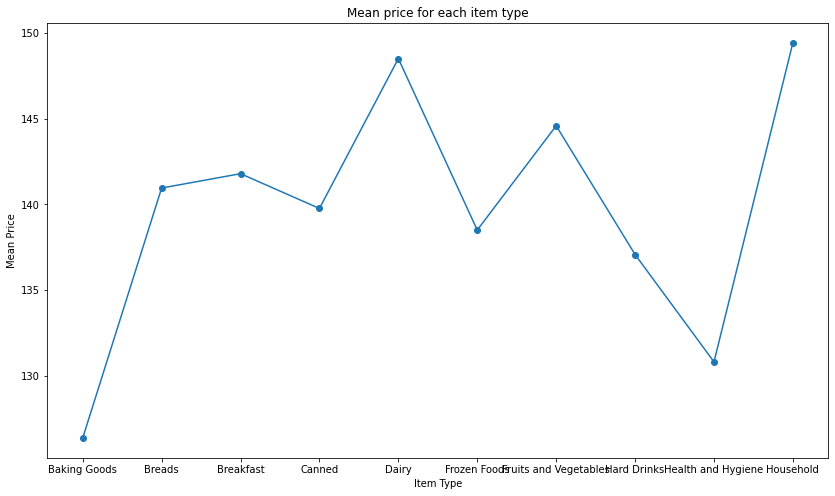

In [58]:
plt.figure(figsize=(14,8))
plt.title('Mean price for each item type')
plt.xlabel('Item Type')
plt.ylabel('Mean Price')

plt.xticks(labels=price_item.index, ticks=np.arange(len(price_item)))
plt.plot(price_item.index, price_item.values, marker='o')

In [59]:
price_item = df.groupby('Outlet_Size').Item_Outlet_Sales.mean()
price_item

Outlet_Size
High      2298.995256
Medium    2681.603542
Small     1912.149161
Name: Item_Outlet_Sales, dtype: float64

<BarContainer object of 3 artists>

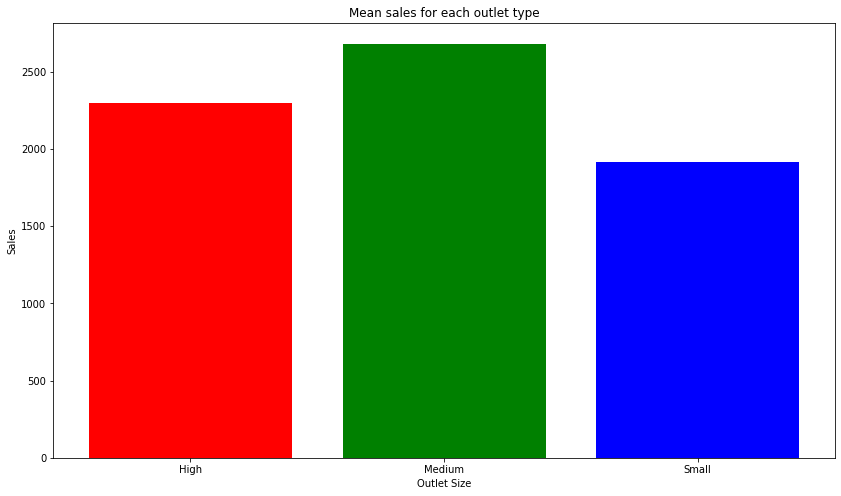

In [60]:
plt.figure(figsize=(14,8))
plt.title('Mean sales for each outlet type')
plt.xlabel('Outlet Size')
plt.ylabel('Sales')

plt.xticks(labels=price_item.index, ticks=np.arange(len(price_item)))
plt.bar(price_item.index, price_item.values, color=['r', 'g', 'b'])

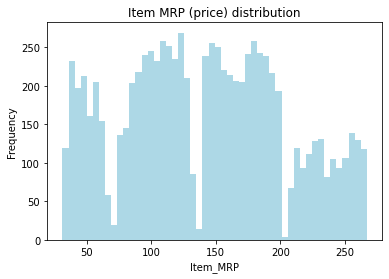

In [64]:
plt.title('Item MRP (price) distribution')
plt.xlabel('Item_MRP')
plt.ylabel('Frequency')
plt.hist(df.Item_MRP, bins=50, color='lightblue');

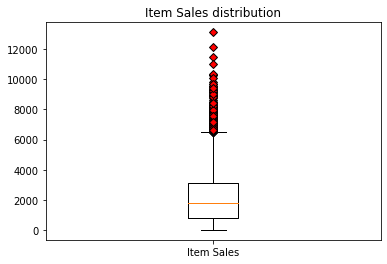

In [71]:
plt.title('Item Sales distribution')
red_diamond = dict(markerfacecolor='r', marker='D')
plt.boxplot(df.Item_Outlet_Sales, labels=['Item Sales'], flierprops=red_diamond);

In [82]:
boxes.values

array([[  9.3   , 249.8092],
       [  5.92  ,  48.2692],
       [ 17.5   , 141.618 ],
       ...,
       [ 10.6   ,  85.1224],
       [  7.21  , 103.1332],
       [ 14.8   ,  75.467 ]])

Text(0.5, 1.0, 'Item Distribution')

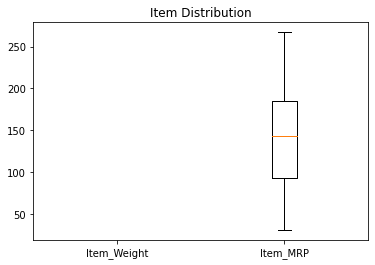

In [86]:
boxes = df[['Item_Weight', 'Item_MRP']]
fig, ax = plt.subplots()
red_diamond = dict(markerfacecolor='r', marker='D')
plt.boxplot(boxes.values, labels=boxes.columns, flierprops=red_diamond);
plt.title('Item Distribution')

Text(0.5, 1.0, 'Item Distribution')

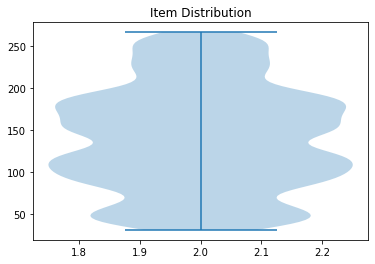

In [95]:
boxes = df[['Item_Weight', 'Item_MRP']]
fig, ax = plt.subplots()
red_diamond = dict(markerfacecolor='r', marker='D')
#plt.xticks(ticks=range(1, 3), labels=boxes.columns)
plt.violinplot(boxes.values);
plt.title('Item Distribution')

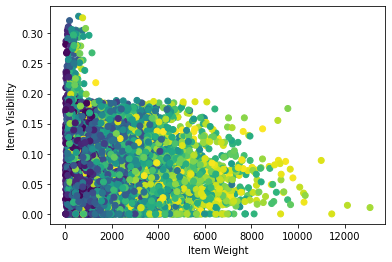

In [105]:
boxes = df[['Item_Outlet_Sales', 'Item_MRP', 'Item_Visibility']]
fig, ax = plt.subplots()
plt.xlabel('Item Weight')
plt.ylabel('Item Visibility')
plt.scatter(boxes.Item_Outlet_Sales, boxes.Item_Visibility, c=boxes.Item_MRP) #s=boxes.Item_Visibility[:10])

In [110]:
sns.set()
sns.set(style='darkgrid')

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=(10, 10)

<AxesSubplot:xlabel='Item_Weight', ylabel='Item_MRP'>

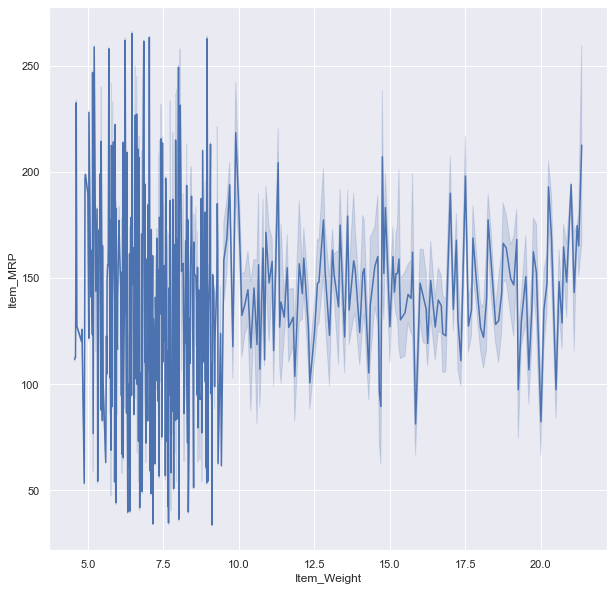

In [111]:
sns.lineplot(data=df, x='Item_Weight', y='Item_MRP')

<AxesSubplot:xlabel='Item_Type', ylabel='Item_MRP'>

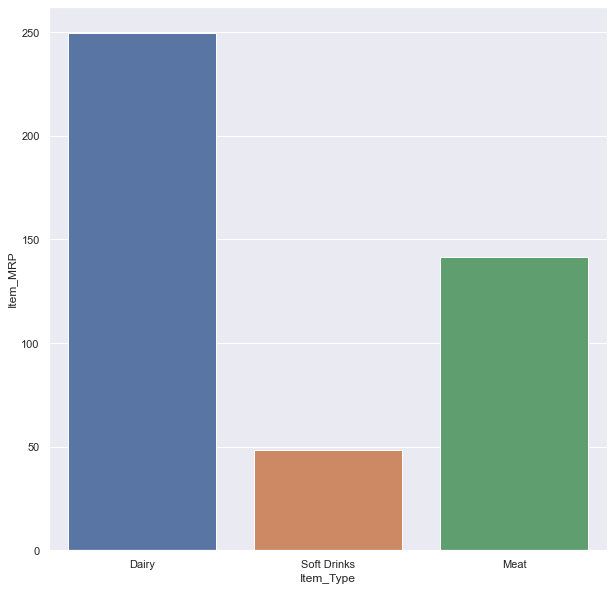

In [119]:
sns.barplot(data=df[:3], x='Item_Type', y='Item_MRP')

<AxesSubplot:ylabel='Density'>

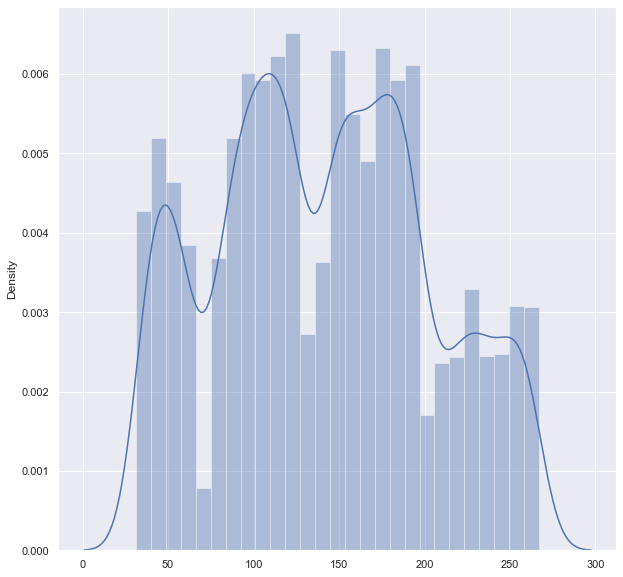

In [122]:
sns.distplot(x=df.Item_MRP)

<AxesSubplot:xlabel='Item_Outlet_Sales'>

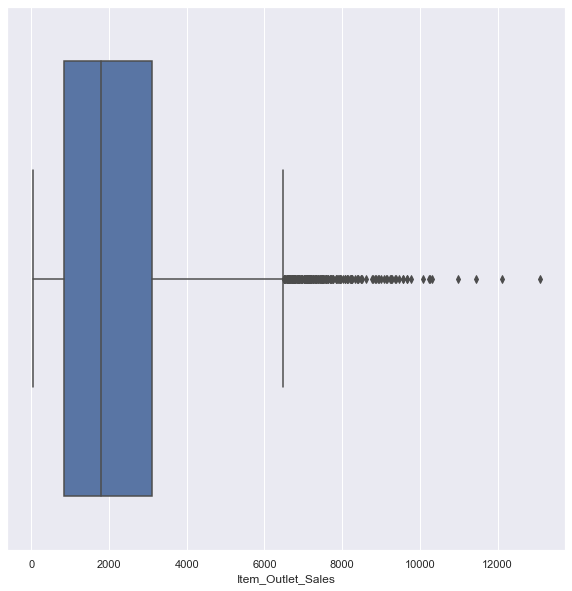

In [127]:
sns.boxplot(df.Item_Outlet_Sales, orient='horizontal')

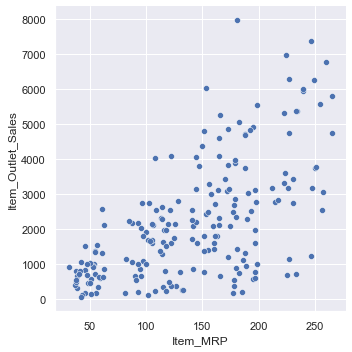

In [128]:
sns.relplot(x='Item_MRP', y='Item_Outlet_Sales', data=df[:200], kind='scatter')

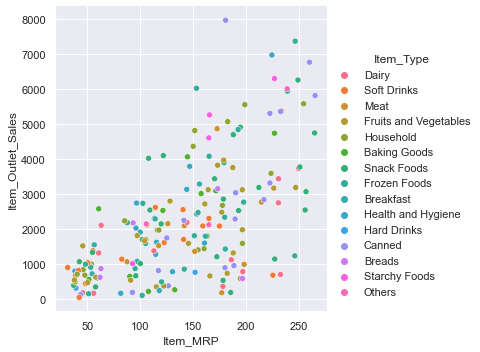

In [129]:
sns.relplot(x='Item_MRP', y='Item_Outlet_Sales', hue='Item_Type', data=df[:200], kind='scatter')

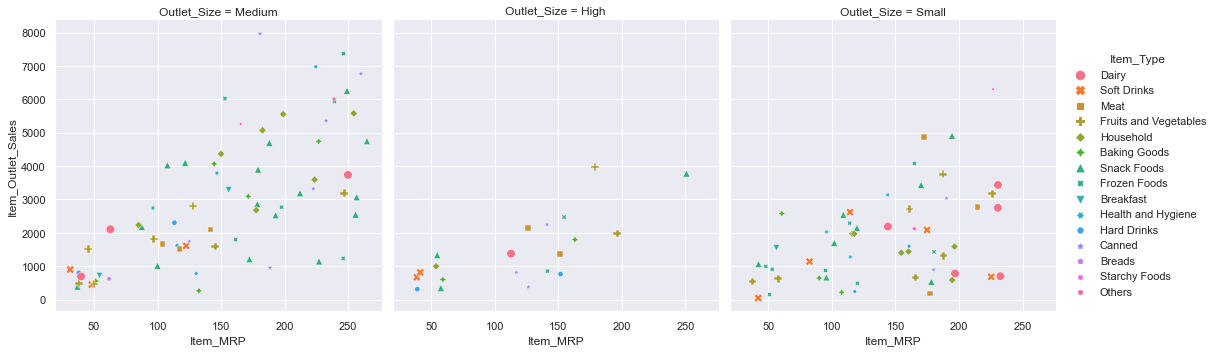

In [138]:
sns.relplot(x='Item_MRP', 
            y='Item_Outlet_Sales', 
            style='Item_Type', 
            size='Item_Type', 
            hue='Item_Type', 
            col='Outlet_Size',
            data=df[:200], 
            kind='scatter')

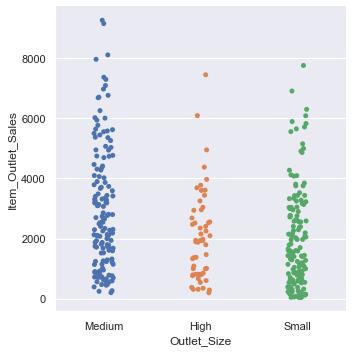

In [142]:
sns.catplot(x='Outlet_Size',
           y='Item_Outlet_Sales',
           kind='strip',
           data=df[:500])

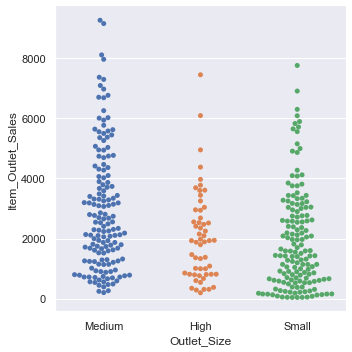

In [143]:
sns.catplot(x='Outlet_Size',
           y='Item_Outlet_Sales',
           kind='swarm',
           data=df[:500])

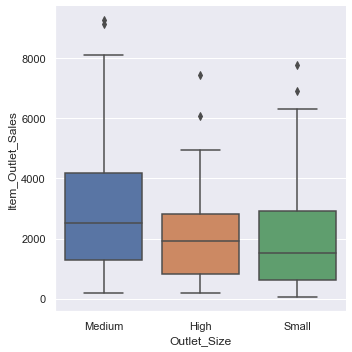

In [144]:
sns.catplot(x='Outlet_Size',
           y='Item_Outlet_Sales',
           kind='box',
           data=df[:500])

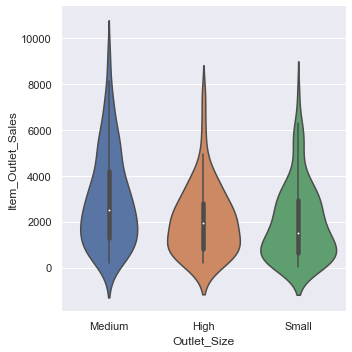

In [145]:
sns.catplot(x='Outlet_Size',
           y='Item_Outlet_Sales',
           kind='violin',
           data=df[:500])

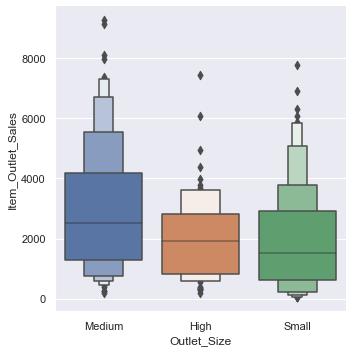

In [146]:
sns.catplot(x='Outlet_Size',
           y='Item_Outlet_Sales',
           kind='boxen',
           data=df[:500])

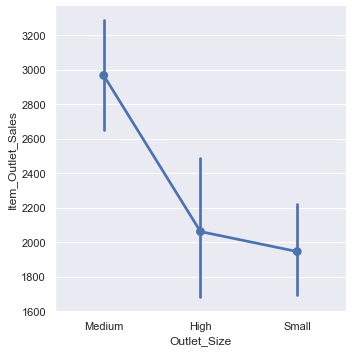

In [147]:
sns.catplot(x='Outlet_Size',
           y='Item_Outlet_Sales',
           kind='point',
           data=df[:500])

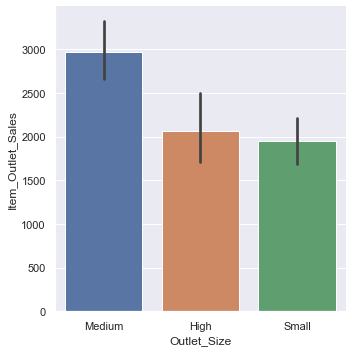

In [148]:
sns.catplot(x='Outlet_Size',
           y='Item_Outlet_Sales',
           kind='bar',
           data=df[:500])

<AxesSubplot:xlabel='Item_Visibility', ylabel='Density'>

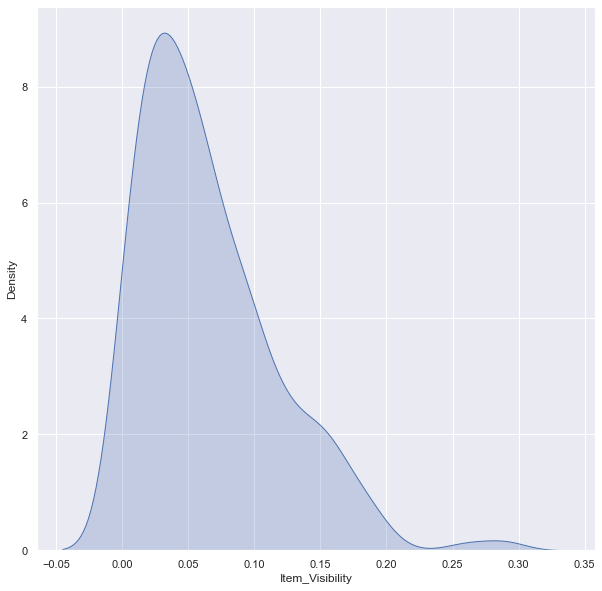

In [150]:
sns.kdeplot('Item_Visibility',
           data=df[:500],
           shade=True)

<AxesSubplot:xlabel='Item_Visibility', ylabel='Density'>

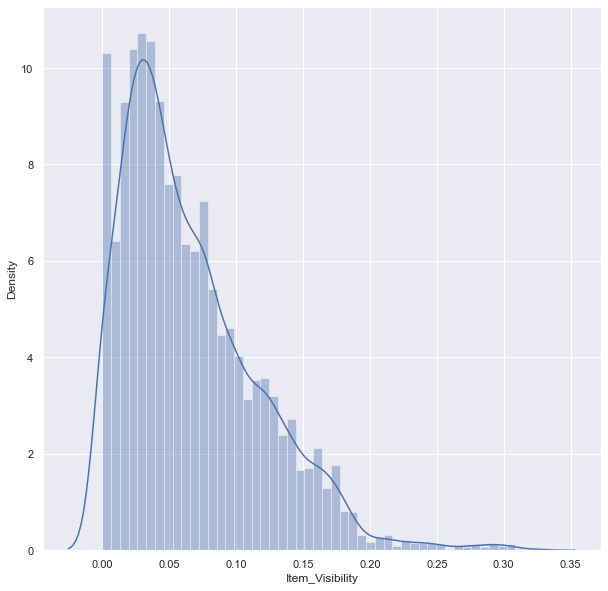

In [153]:
sns.distplot(df.Item_Visibility)

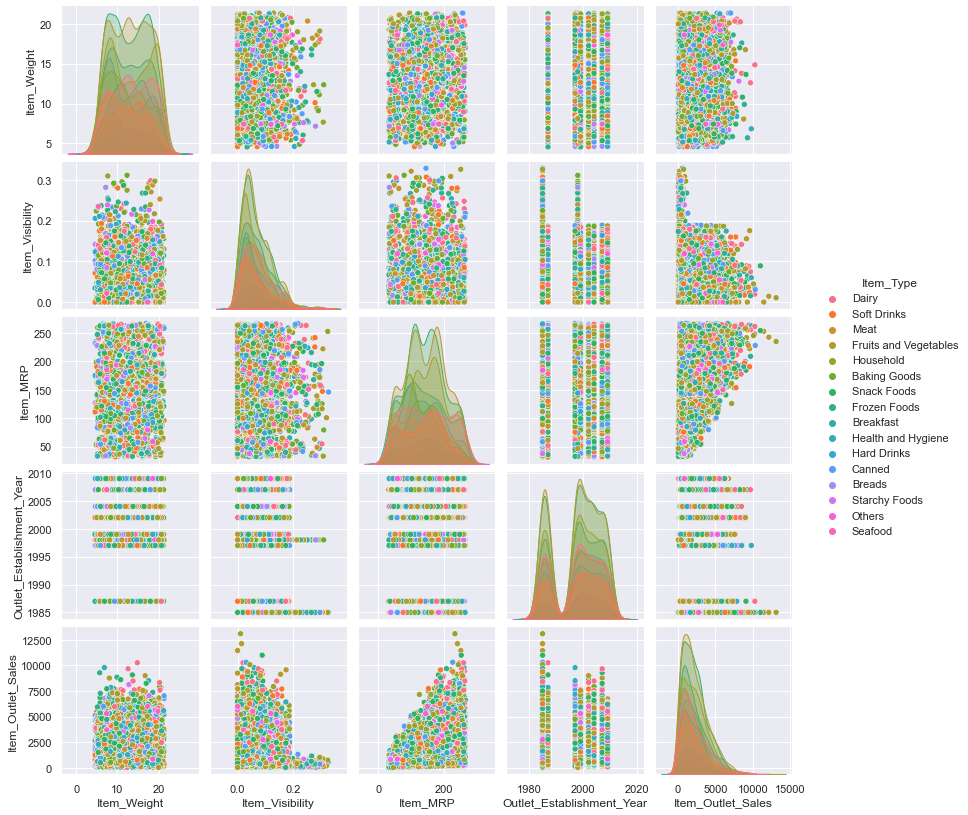

In [154]:
sns.pairplot(df, hue='Item_Type', height=2.3)